# Model and interpretation

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

import random
import numpy as np
random.seed(42)
np.random.seed(42)

In [2]:
import pandas as pd

features_df = pd.read_csv('../data/processed/features.csv')

In [3]:
TARGET = ['monthly_revenue']
DROP_COLUMNS = ['location_id', 'lat', 'lng']
y = features_df[TARGET]
X = features_df.drop(DROP_COLUMNS + TARGET, axis=1)

RADIUS = 1500
RETRAIN_MODEL = True

Let's inspect the correlation of each feature with `monthly_revenue` - our target variable.

<Axes: >

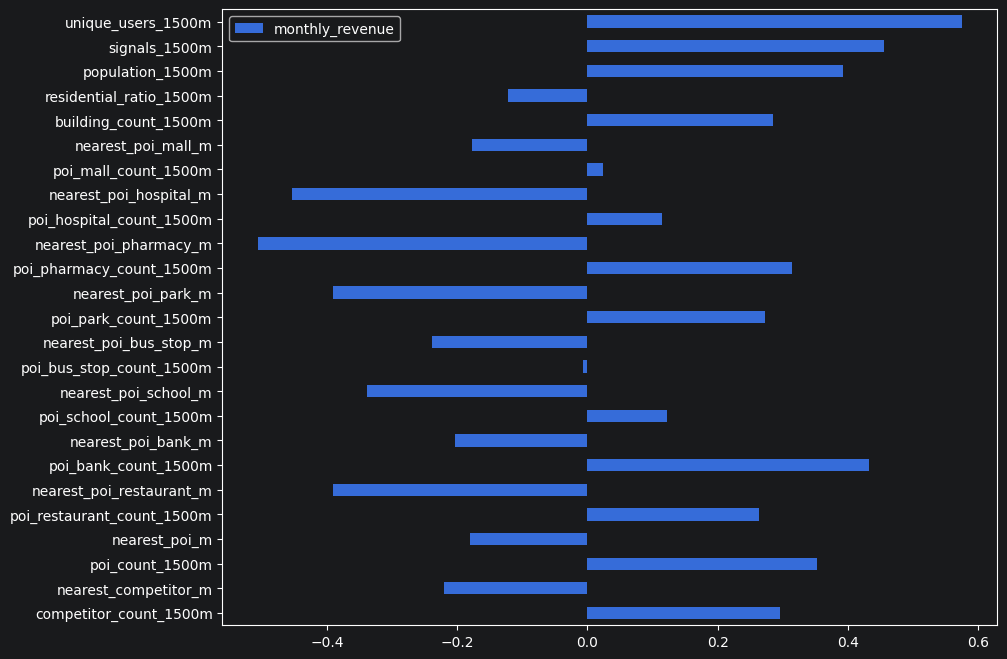

In [4]:
correlation_with_target = features_df.drop(DROP_COLUMNS, axis=1).corr()[TARGET].drop(TARGET, errors='ignore')
correlation_with_target.plot(kind='barh', figsize=(10, 8))

In [40]:
print(f"Columns displaying an absolute correlation of above 0.4: {correlation_with_target[abs(correlation_with_target['monthly_revenue']) > 0.3]}")

Columns displaying an absolute correlation of above 0.4:                           monthly_revenue
poi_count_1500m                  0.352961
nearest_poi_restaurant_m        -0.390620
poi_bank_count_1500m             0.432200
nearest_poi_school_m            -0.338258
nearest_poi_park_m              -0.390726
poi_pharmacy_count_1500m         0.314645
nearest_poi_pharmacy_m          -0.506551
nearest_poi_hospital_m          -0.453058
population_1500m                 0.391774
signals_1500m                    0.455259
unique_users_1500m               0.575228


Let's also plot a correlation heatmap between all features

In [6]:
import numpy as np

def plot_corr_heatmap(
    corr: pd.DataFrame,
    *,
    title: str = "Correlation (Spearman/Pearson)",
    mask_upper: bool = True,
    annotate: bool = False,
    figsize: tuple[float, float] | None = None,
) -> None:
    """Plot a correlation heatmap using matplotlib."""
    corr_vals = corr.values.copy()

    if mask_upper:
        mask = np.triu(np.ones_like(corr_vals, dtype=bool), k=1)
        corr_plot = np.ma.array(corr_vals, mask=mask)
    else:
        corr_plot = corr_vals

    n = corr.shape[0]
    if figsize is None:
        figsize = (max(6.0, 0.5 * n), max(5.0, 0.5 * n))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr_plot, vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="corr")

    ax.set_title(title)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(n):
            for j in range(n):
                if mask_upper and j > i:
                    continue
                value = corr_vals[i, j]
                if np.isnan(value):
                    continue
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


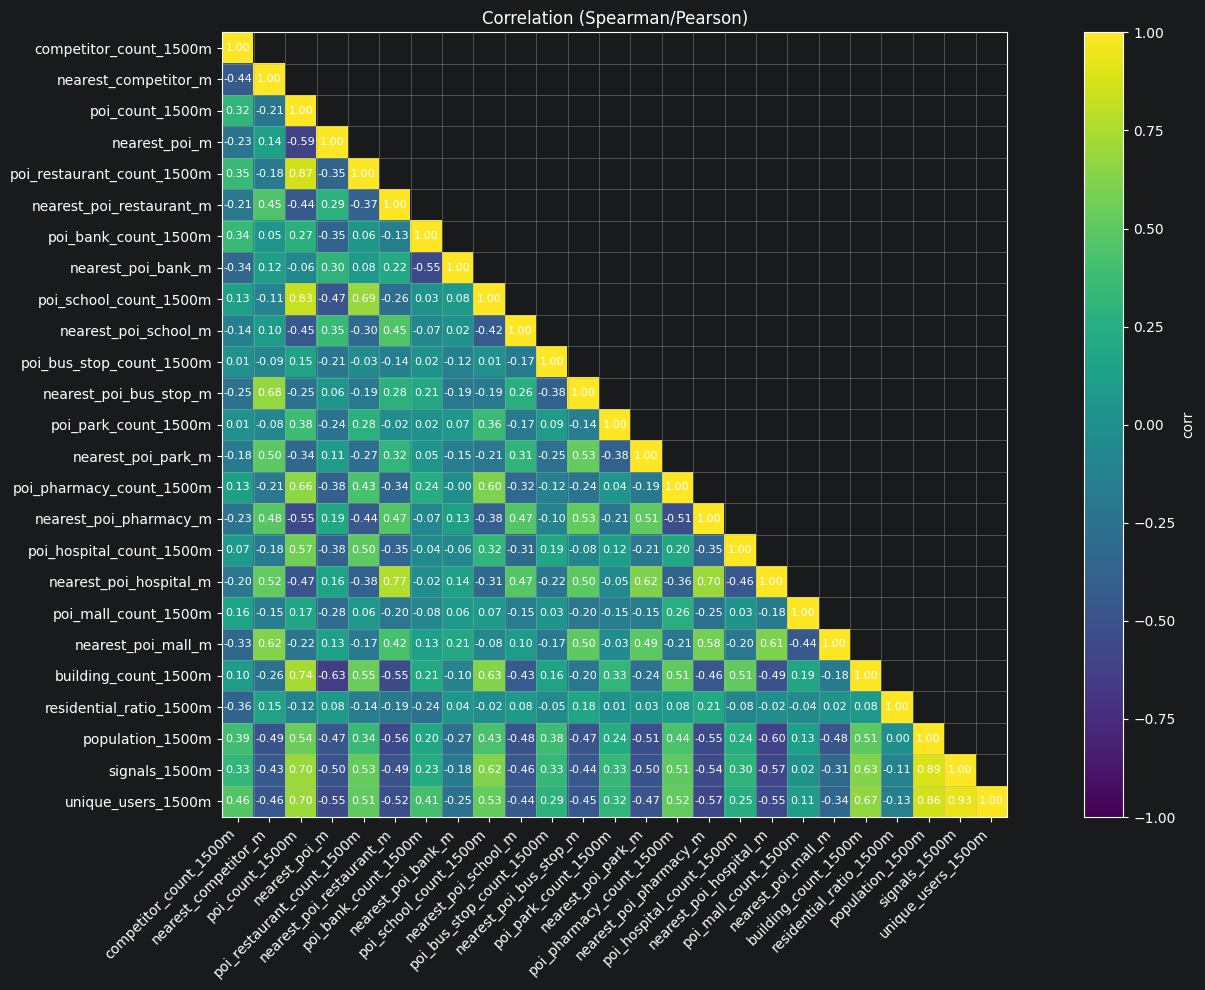

In [7]:
correlations = X.corr()
plot_corr_heatmap(correlations, mask_upper=True, annotate=True, figsize=(20, 10))

Number of unique users, number of signals and total population in 1500-meter radius are strongly, positively correlated.

The primary constraint is dataset size — 50 observations across 26 features yields a feature-to-sample ratio of 1:2, which severely limits model complexity and makes overfitting the main risk to manage.

The most important thing with such small population sizes is regularization, which prevents overfitting. Brief suggested building an XBoost Regression model. I will also test regularized linear regression models (Ridge & LASSO) and SVM.

#### Model comparison

Before training any model, we can create a naive mean-predictor baseline - such that would achieve an R² score of 0.

In [8]:
from sklearn.metrics import r2_score, root_mean_squared_error

baseline_predictions = np.full(len(y), y.mean())
baseline_r2 = r2_score(y, baseline_predictions)
baseline_rmse = root_mean_squared_error(y, baseline_predictions)
print(f"Baseline R²: {baseline_r2:.3f}")
print(f"Baseline RMSE: {baseline_rmse:,.3f}")

Baseline R²: 0.000
Baseline RMSE: 106,966.317


Results of all models will be saved

In [9]:
results = []
results.append({
    'attempt': 0,
    'model': 'Baseline naive mean-predictor',
    'features': 'full (26)',
    'cv': np.nan,
    'target': 'raw',
    'r2_mean': baseline_r2,
    'r2_std': np.nan,
    'rmse_mean': baseline_rmse,
    'rmse_std': np.nan,
    'rmse_unit': 'PLN'
})

Let's train the first model. XGBoost was suggested in the brief, so let's try out a simple XGBRegressor with regularization.

In [10]:
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score

xboost_model = XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=1,
)

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
r2_1 = cross_val_score(xboost_model, X, y, cv=rkf, scoring='r2')
rmse_1 = cross_val_score(xboost_model, X, y, cv=rkf, scoring='neg_root_mean_squared_error')

print(f"R² mean: {r2_1.mean():.3f} ± {r2_1.std():.3f}")
print(f"RMSE mean: {-rmse_1.mean():.3f} ± {rmse_1.std():.3f}")

R² mean: 0.175 ± 0.453
RMSE mean: 83598.553 ± 23754.454


The regularized XGBoost achieves CV R²=0.175 ± 0.453, meaning the model explains ~17% of revenue variance attributable to location characteristics. RMSE of ~84k PLN compares favourably to a naive mean-predictor baseline of ~107k PLN — a 21% improvement.

The high standard deviation (±0.453) reflects instability inherent to 5-fold CV at n=50 — individual fold results vary widely depending
on which locations end up in the test set. RepeatedKFold (5×10) mitigates this by averaging over 50 different splits.

Let's try to tune the hyperparameters of the model.

Hyperparameter search was performed iteratively — initial broad grid identified promising ranges, which were then refined in a narrower search.

Best params from an initial run: learning_rate=0.2, max_depth=2, reg_alpha=50.0, colsample_bytree=0.3, subsample=0.7.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.15, 0.2, 0.3],
    'reg_alpha': [45.0, 50.0, 55.0],
    'reg_lambda': [1.0, 2.0],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.3, 0.4, 0.5],
}

grid_search = GridSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid,
    cv=rkf,
    scoring='r2',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Best params: {grid_search.best_params_}")

Fitting 50 folds for each of 648 candidates, totalling 32400 fits
Best params: {'colsample_bytree': 0.4, 'learning_rate': 0.15, 'max_depth': 2, 'n_estimators': 50, 'reg_alpha': 55.0, 'reg_lambda': 2.0, 'subsample': 0.8}


In [12]:
xboost_model_tuned = grid_search.best_estimator_

r2_2 = cross_val_score(xboost_model_tuned, X, y, cv=rkf, scoring='r2')
rmse_2 = cross_val_score(xboost_model_tuned, X, y, cv=rkf, scoring='neg_root_mean_squared_error')
print(f"Best R²: {r2_2.mean():.3f} ± {r2_2.std():.3f}")
print(f"Best RMSE: {-rmse_2.mean():.3f} ± {rmse_2.std():.3f}")

Best R²: 0.152 ± 0.465
Best RMSE: 84600.868 ± 23254.999


GridSearch identified hyperparameters with marginally higher CV R² in some runs, but results proved unstable across sessions.

With only 50 training observations, the variance in CV scores is high enough that differences between model configurations are not statistically
meaningful. A simpler, regularized baseline XGBoost is selected for further comparison — it is more reproducible and less prone to hyperparameter
overfitting than a grid-searched configuration.

In [13]:
results.append({
    'attempt': 1,
    'model': 'XGBoost regularized',
    'features': 'full (26)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'raw',
    'r2_mean': r2_1.mean(),
    'r2_std': r2_1.std(),
    'rmse_mean': -rmse_1.mean(),
    'rmse_std': rmse_1.std(),
    'rmse_unit': 'PLN'
})

results.append({
    'attempt': 2,
    'model': 'XGBoost regularized tuned',
    'features': 'full (26)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'raw',
    'r2_mean': r2_2.mean(),
    'r2_std': r2_2.std(),
    'rmse_mean': -rmse_2.mean(),
    'rmse_std': rmse_2.std(),
    'rmse_unit': 'PLN'
})

Let's train the same model using only the features that are the most correlated with our target. If features are correlated between each other, one of a group will be chosen.

In [14]:
correlation_with_target[abs(correlation_with_target['monthly_revenue']) > 0.3].sort_values(by='monthly_revenue', ascending=False)

,monthly_revenue
unique_users_1500m,0.575228
signals_1500m,0.455259
poi_bank_count_1500m,0.432200
population_1500m,0.391774
poi_count_1500m,0.352961
poi_pharmacy_count_1500m,0.314645
nearest_poi_school_m,-0.338258
nearest_poi_restaurant_m,-0.390620
nearest_poi_park_m,-0.390726
nearest_poi_hospital_m,-0.453058


11 features were returned. Out of correlated features: `unique_users_1500m`, `signals_1500m`, `population_1500m`, we will keep `unique_users_1500m`, since it is the most strongly correlated with our target.

That leaves us with 9 features:

In [15]:
SELECTED_FEATURES_1 = [
    f'unique_users_{RADIUS}m',
    f'poi_bank_count_{RADIUS}m',
    f'poi_count_{RADIUS}m',
    f'poi_pharmacy_count_{RADIUS}m',
    'nearest_poi_school_m',
    'nearest_poi_restaurant_m',
    'nearest_poi_park_m',
    'nearest_poi_hospital_m',
    'nearest_poi_pharmacy_m'
]

In [16]:
X_selected_1 = X[SELECTED_FEATURES_1]
r2_3 = cross_val_score(xboost_model, X_selected_1, y, cv=rkf, scoring='r2')
rmse_3 = cross_val_score(xboost_model, X_selected_1, y, cv=rkf, scoring='neg_root_mean_squared_error')
print(f"R² mean for selected features: {r2_3.mean():.3f} ± {r2_3.std():.3f}")
print(f"RMSE mean for selected features: {-rmse_3.mean():.3f} ± {rmse_3.std():.3f}")

R² mean for selected features: 0.124 ± 0.523
RMSE mean for selected features: 85665.772 ± 23337.778


Performance of the model did not improve.

In [17]:
results.append({
    'attempt': 3,
    'model': 'XGBoost regularized',
    'features': 'correlated (9)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'raw',
    'r2_mean': r2_3.mean(),
    'r2_std': r2_3.std(),
    'rmse_mean': -rmse_3.mean(),
    'rmse_std': rmse_3.std(),
    'rmse_unit': 'PLN'
})

Let's try some other models - let's begin with regularized linear models. Monthly revenue is right-skewed (skewness = 1.15), violating the normality assumption of linear models. Therefore, log-transformation will be applied to stabilize
variance and reduce skew.

In [18]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import GridSearchCV

y_log = np.log(y)

ridge_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Ridge(max_iter=10000))]),
    param_grid=ridge_param_grid,
    cv=rkf,
    scoring='r2',
    n_jobs=1
)
ridge_grid.fit(X, y_log)
print(f"Ridge best params: {ridge_grid.best_params_}")
print(f"Ridge best R²: {ridge_grid.best_score_:.3f}")

# Lasso GridSearch
lasso_param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
    param_grid=lasso_param_grid,
    cv=rkf,
    scoring='r2',
    n_jobs=1
)
lasso_grid.fit(X, y_log)
print(f"Lasso best params: {lasso_grid.best_params_}")
print(f"Lasso best R²: {lasso_grid.best_score_:.3f}")

# Evaluate best models with RKF
ridge_model = ridge_grid.best_estimator_
lasso_model = lasso_grid.best_estimator_

r2_4 = cross_val_score(ridge_model, X, y_log, cv=rkf, scoring='r2')
rmse_4 = cross_val_score(ridge_model, X, y_log, cv=rkf, scoring='neg_root_mean_squared_error')
r2_5 = cross_val_score(lasso_model, X, y_log, cv=rkf, scoring='r2')
rmse_5 = cross_val_score(lasso_model, X, y_log, cv=rkf, scoring='neg_root_mean_squared_error')

print(f"Ridge R² mean for full features: {r2_4.mean():.3f} ± {r2_4.std():.3f}")
print(f"Ridge RMSE mean for full features: {-rmse_4.mean():.3f} ± {rmse_4.std():.3f}")
print(f"Lasso R² mean for full features: {r2_5.mean():.3f} ± {r2_5.std():.3f}")
print(f"Lasso RMSE mean for full features: {-rmse_5.mean():.3f} ± {rmse_5.std():.3f}")

Ridge best params: {'model__alpha': 100.0}
Ridge best R²: 0.033
Lasso best params: {'model__alpha': 0.1}
Lasso best R²: -0.141
Ridge R² mean for full features: 0.033 ± 0.271
Ridge RMSE mean for full features: 0.363 ± 0.114
Lasso R² mean for full features: -0.141 ± 0.420
Lasso RMSE mean for full features: 0.387 ± 0.113


The performance of these models is significantly poorer, comparable or worse to our baseline naive mean-predictor.

Notably, RMSE reported for log-transformed models is in log(PLN) units and cannot be directly compared to RMSE from tree-based models (PLN units).

In [19]:
results.append({
    'attempt': 4,
    'model': 'Linear (Ridge regularization) tuned',
    'features': 'full (26)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'log-transformed',
    'r2_mean': r2_4.mean(),
    'r2_std': r2_4.std(),
    'rmse_mean': -rmse_4.mean(),
    'rmse_std': rmse_4.std(),
    'rmse_unit': 'log(PLN)'
})

results.append({
    'attempt': 5,
    'model': 'Linear (LASSO regularization) tuned',
    'features': 'full (26)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'log-transformed',
    'r2_mean': r2_5.mean(),
    'r2_std': r2_5.std(),
    'rmse_mean': -rmse_5.mean(),
    'rmse_std': rmse_5.std(),
    'rmse_unit': 'log(PLN)'
})

Let's try SVM on full features.

In [20]:
from sklearn.svm import SVR

svr_param_grid = {
    'model__C': [0.1, 1.0, 10.0, 100.0],
    'model__epsilon': [0.01, 0.1, 0.5],
    'model__kernel': ['rbf', 'linear']
}

svr_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', SVR())]),
    param_grid=svr_param_grid,
    cv=rkf,
    scoring='r2',
    n_jobs=1
)
svr_grid.fit(X, y_log.values.ravel())
print(f"SVR best params: {svr_grid.best_params_}")
print(f"SVR best R²: {svr_grid.best_score_:.3f}")

svr_model = svr_grid.best_estimator_

r2_6 = cross_val_score(svr_model, X, y_log.values.ravel(), cv=rkf, scoring='r2')
rmse_6 = cross_val_score(svr_model, X, y_log.values.ravel(), cv=rkf, scoring='neg_root_mean_squared_error')

print(f"SVR R² mean: {r2_6.mean():.3f} ± {r2_6.std():.3f}")
print(f"SVR RMSE mean: {-rmse_6.mean():.3f} ± {rmse_6.std():.3f}")

SVR best params: {'model__C': 0.1, 'model__epsilon': 0.01, 'model__kernel': 'rbf'}
SVR best R²: -0.053
SVR R² mean: -0.053 ± 0.184
SVR RMSE mean: 0.383 ± 0.120


Again, the model is worse than our baseline mean-predictor.

In [21]:
results.append({
    'attempt': 6,
    'model': 'SVM tuned',
    'features': 'full (26)',
    'cv': 'RepeatedKFold-5x10',
    'target': 'log-transformed',
    'r2_mean': r2_6.mean(),
    'r2_std': r2_6.std(),
    'rmse_mean': -rmse_6.mean(),
    'rmse_std': rmse_6.std(),
    'rmse_unit': 'log(PLN)'
})

An attempt was made to enrich the feature set with store-level building data. By spatially joining `gdf_locations` with `gdf_buildings`, each store was
matched to its building polygon, yielding two additional features: `store_building_area` and `is_retail_building` (whether the building is dedicated commercial space).

Note that `store_building_area` reflects the entire building area, not the store's actual floor area — a store may occupy only part of a
larger mixed-use building. Despite this limitation, building size and type were hypothesized to correlate with revenue.

New features were computed in `02_feature_engineering.ipynb` and saved in `features_2.csv`

Let's load the new feature set and repeat the initial phase of modelling.

In [22]:
features_df_2 = pd.read_csv('../data/processed/features_2.csv')

In [23]:
y_2 = features_df_2[TARGET]
X_2 = features_df_2.drop(DROP_COLUMNS + TARGET, axis=1)

<Axes: >

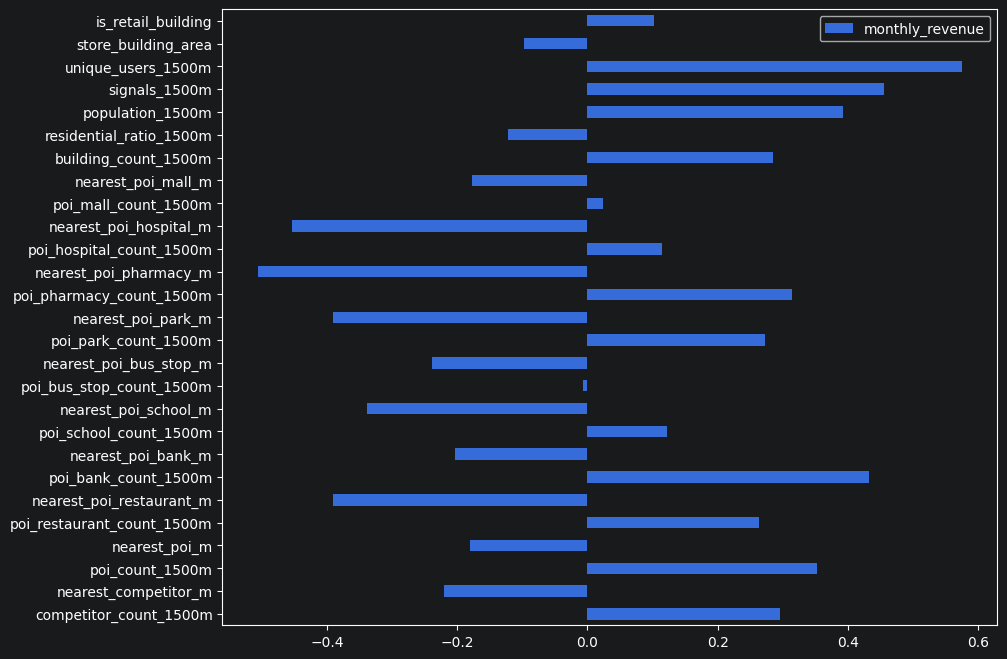

In [24]:
correlation_with_target_2 = features_df_2.drop(DROP_COLUMNS, axis=1).corr()[TARGET].drop(TARGET, errors='ignore')
correlation_with_target_2.plot(kind='barh', figsize=(10, 8))

Our hypothesis was false in that `store_building_area` is not correlated with our target variable.

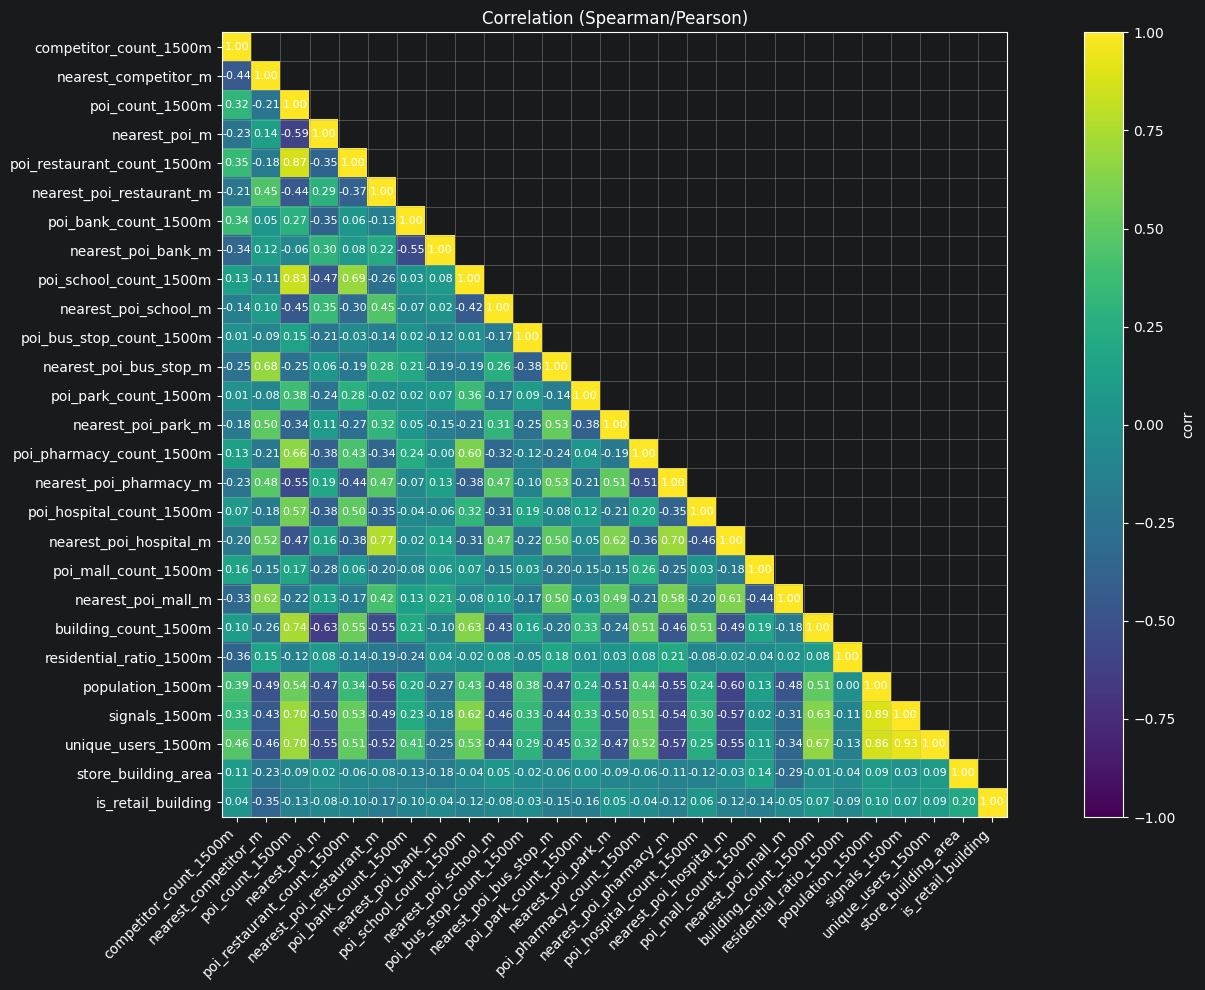

In [25]:
correlations_2 = X_2.corr()
plot_corr_heatmap(correlations_2, mask_upper=True, annotate=True, figsize=(20, 10))

Let's train the best model from previous phase on the new feature set.

In [26]:
r2_7 = cross_val_score(xboost_model, X_2, y_2, cv=rkf, scoring='r2')
rmse_7 = cross_val_score(xboost_model, X_2, y_2, cv=rkf, scoring='neg_root_mean_squared_error')

print(f"R² mean: {r2_7.mean():.3f} ± {r2_7.std():.3f}")
print(f"RMSE mean: {-rmse_7.mean():.3f} ± {rmse_7.std():.3f}")

R² mean: 0.140 ± 0.466
RMSE mean: 85802.172 ± 23212.174


The performance difference is not statistically meaningful at n=50.

In [27]:
results.append({
    'attempt': 7,
    'model': 'XBoost regularized',
    'features': 'extended with buildings data',
    'cv': 'RepeatedKFold-5x10',
    'target': 'raw',
    'r2_mean': r2_7.mean(),
    'r2_std': r2_7.std(),
    'rmse_mean': -rmse_7.mean(),
    'rmse_std': rmse_7.std(),
    'rmse_unit': 'PLN'
})

We noticed before that `signals_1500m` and `unique_users_1500m` were highly correlated. We can try to divide these two values to obtain a number of signals per user, which may indicate loyalty - how often a particular user was present on average in the area.

In [28]:
features_df['signals_per_user'] = (
    features_df[f'signals_{RADIUS}m'] / features_df[f'unique_users_{RADIUS}m']
)

In [29]:
X_3 = features_df.drop(DROP_COLUMNS + TARGET, axis=1)

<Axes: >

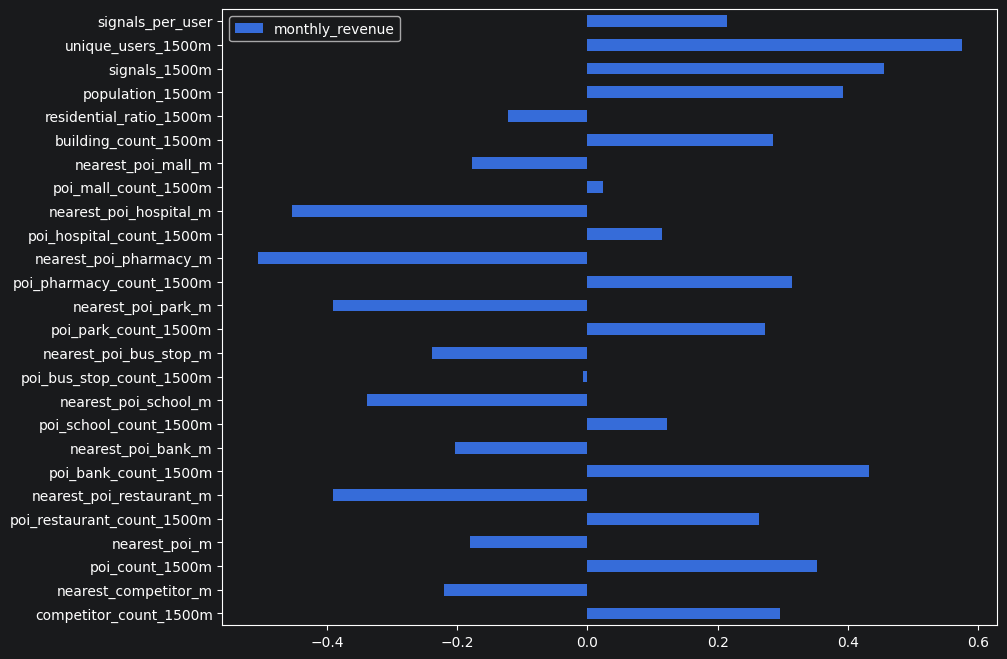

In [30]:
correlation_with_target_3 = features_df.drop(DROP_COLUMNS, axis=1).corr()[TARGET].drop(TARGET, errors='ignore')
correlation_with_target_3.plot(kind='barh', figsize=(10, 8))

We notice that `signals_per_user` is not as correlated with our target as its two 'parent' features.

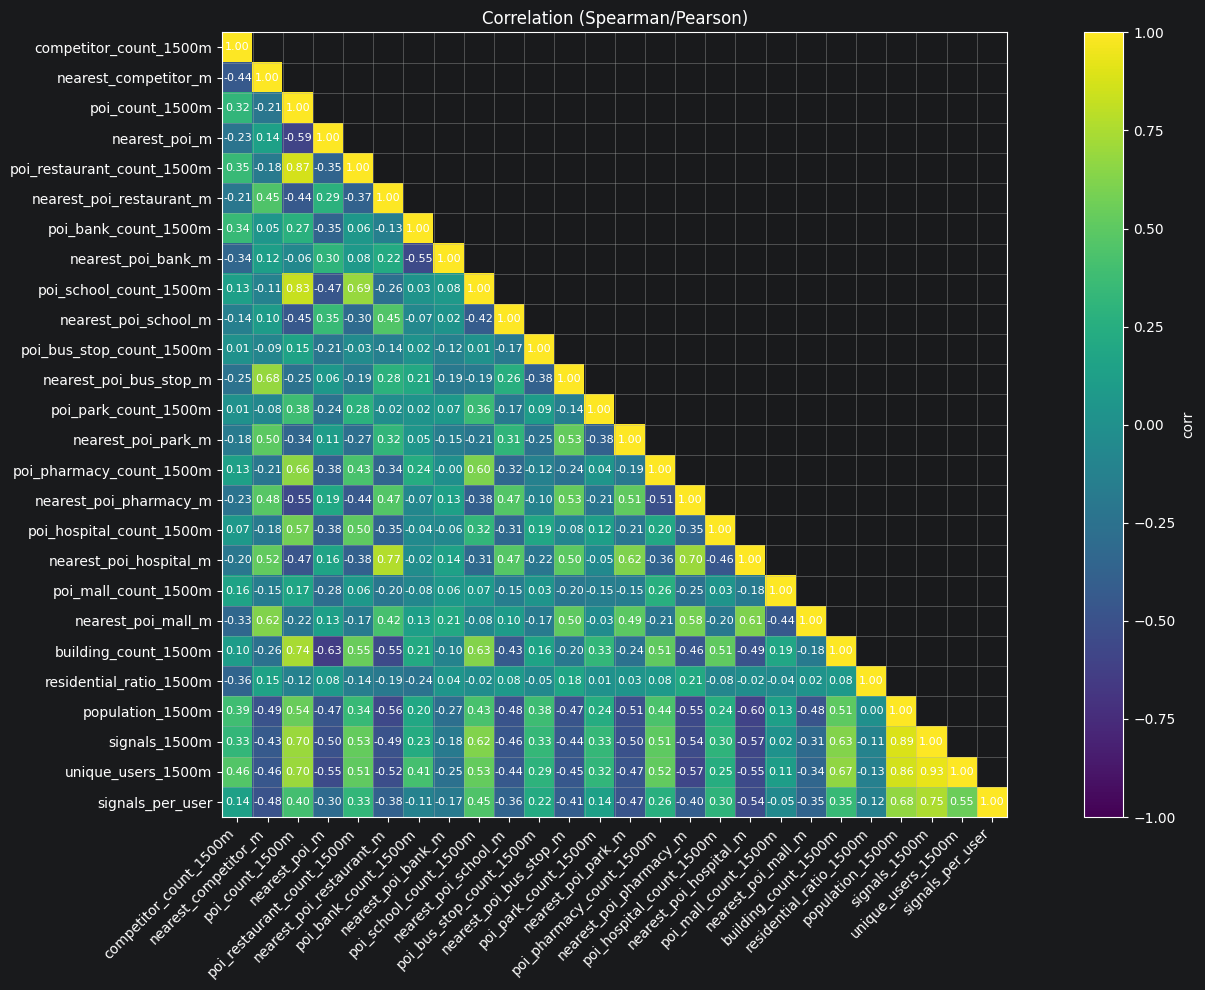

In [31]:
correlations_3 = X_3.corr()
plot_corr_heatmap(correlations_3, mask_upper=True, annotate=True, figsize=(20, 10))

In [32]:
r2_8 = cross_val_score(xboost_model, X_3, y, cv=rkf, scoring='r2')
rmse_8 = cross_val_score(xboost_model, X_3, y, cv=rkf, scoring='neg_root_mean_squared_error')

print(f"R² mean: {r2_8.mean():.3f} ± {r2_8.std():.3f}")
print(f"RMSE mean: {-rmse_8.mean():.3f} ± {rmse_8.std():.3f}")

R² mean: 0.180 ± 0.395
RMSE mean: 84344.721 ± 23801.087


The performance difference is not statistically meaningful at n=50.

In [33]:
results.append({
    'attempt': 8,
    'model': 'XBoost regularized',
    'features': 'extended with signals per user',
    'cv': 'RepeatedKFold-5x10',
    'target': 'raw',
    'r2_mean': r2_8.mean(),
    'r2_std': r2_8.std(),
    'rmse_mean': -rmse_8.mean(),
    'rmse_std': rmse_8.std(),
    'rmse_unit': 'PLN'
})

In [34]:
results_df = pd.DataFrame(results)
results_df

,attempt,model,features,cv,target,r2_mean,r2_std,rmse_mean,rmse_std,rmse_unit
0,0,Baseline naive mean-predictor,full (26),NaN,raw,0.000000,NaN,106966.316640,NaN,PLN
1,1,XGBoost regularized,full (26),RepeatedKFold-5x10,raw,0.174951,0.453191,83598.553281,23754.454451,PLN
2,2,XGBoost regularized tuned,full (26),RepeatedKFold-5x10,raw,0.152471,0.465217,84600.867734,23254.999115,PLN
3,3,XGBoost regularized,correlated (9),RepeatedKFold-5x10,raw,0.123821,0.523383,85665.772422,23337.777795,PLN
4,4,Linear (Ridge regularization) tuned,full (26),RepeatedKFold-5x10,log-transformed,0.032856,0.271224,0.363003,0.114278,log(PLN)
5,5,Linear (LASSO regularization) tuned,full (26),RepeatedKFold-5x10,log-transformed,-0.140682,0.419615,0.387486,0.113129,log(PLN)
6,6,SVM tuned,full (26),RepeatedKFold-5x10,log-transformed,-0.052748,0.183935,0.383090,0.119958,log(PLN)
7,7,XBoost regularized,extended with buildings data,RepeatedKFold-5x10,raw,0.139886,0.465897,85802.171797,23212.173903,PLN
8,8,XBoost regularized,extended with signals per user,RepeatedKFold-5x10,raw,0.180473,0.394849,84344.720625,23801.087002,PLN


## Summary

The feature set focuses on spatial neighborhood characteristics — foot traffic, demographics, POI density, competition — which are the primary drivers of location potential. This is intentional: the model is designed to evaluate locations before a store opens, so store-specific factors (assortment, pricing, staff quality) are not relevant inputs.

The remaining unexplained variance in revenue likely reflects operational differences between existing stores — factors outside the scope of location analysis. With a location-focused feature set, CV R²=0.175 (XGBoost, RepeatedKFold) represents the portion of revenue variance attributable to location characteristics alone.

The regularized baseline XGBoost was selected as the final model
(CV R²=0.175 ± 0.453, RMSE=84k PLN). GridSearch and feature engineering
extensions (signals_per_user, building features) yielded marginal score
differences (±0.02) that fall well within the noise of CV evaluation
at n=50 — none represented a statistically meaningful improvement over
the baseline.

To ensure full reproducibility, the model is trained with `n_jobs=1`
and `OMP_NUM_THREADS=1` set globally. This disables parallelism
during training, eliminating non-determinism that arises from the
order of floating-point operations across threads. With these settings,
feature importance scores and predictions are now identical across
sessions and kernel restarts.

The trade-off is slower training, which is acceptable for a one-time
fit on 50 observations. The final model will be saved to
`data/processed/model.joblib` along with `feature_importance.csv`
to ensure consistency between Task 3 analysis and Task 4 whitespot scoring.

Let's fit the model on our full dataset and inspect feature importance.

In [41]:
import joblib
import matplotlib.pyplot as plt

if RETRAIN_MODEL:
    xboost_model.fit(X, y)
    joblib.dump(xboost_model, '../data/processed/model.joblib')
    results_df.to_csv('../data/processed/model_results.csv', index=False)

    importance = pd.Series(
        xboost_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    importance.to_csv('../data/processed/feature_importance.csv')
    print("Model retrained and saved")
else:
    xboost_model = joblib.load('../data/processed/model.joblib')
    importance = pd.read_csv('../data/processed/feature_importance.csv')
    print("Model loaded from disk")

Model retrained and saved


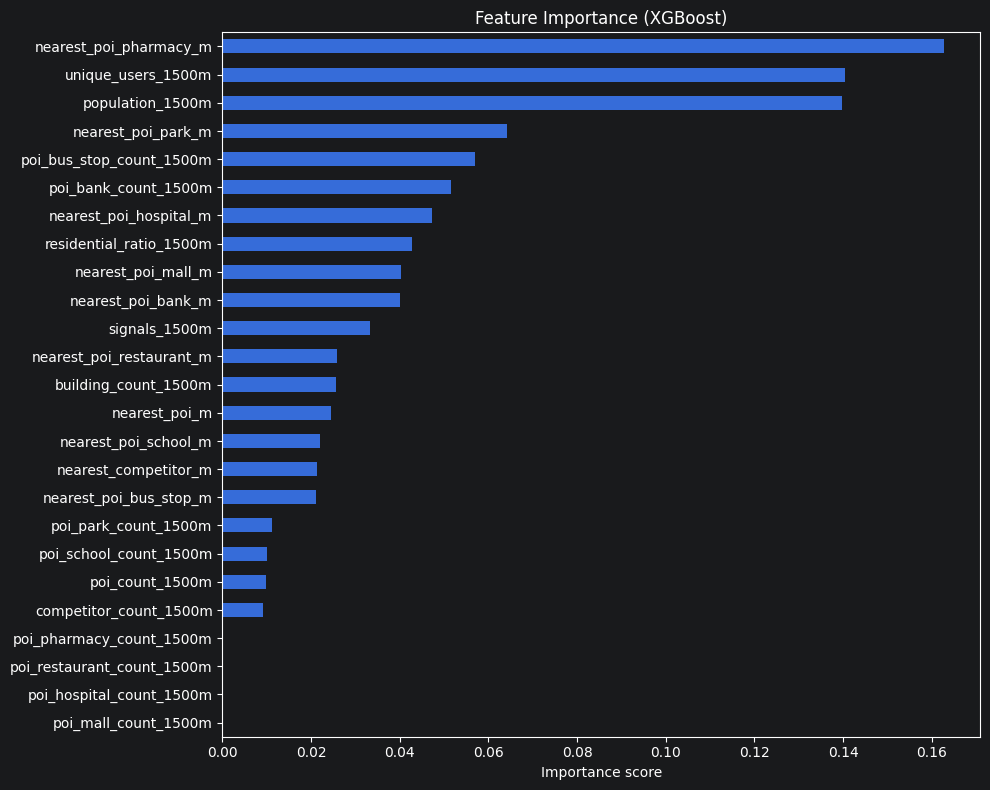

In [42]:
importance.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Earlier iterations of this analysis showed run-to-run variation in feature importance scores (particularly affecting mid-ranked features)
even with `random_state=42` set. This stemmed from XGBoost's internal parallelism — when multiple threads build trees concurrently, the order of floating-point operations can vary between runs, producing slightly different trees and shifting importance scores.

This was resolved by setting `n_jobs=1` on the model and `OMP_NUM_THREADS=1` globally before importing XGBoost. The current feature importance is fully reproducible across sessions and kernel restarts. Results discussed in this notebook reflect the final, stable model configuration.

In [46]:
importance_sorted = importance.sort_values(ascending=False)

print("Top 7 most important features:")
print(importance_sorted.head(5).to_string())
print("\nBottom 7 least important features:")
print(importance_sorted.tail(5).to_string())

Top 7 most important features:
nearest_poi_pharmacy_m      0.162726
unique_users_1500m          0.140380
population_1500m            0.139850
nearest_poi_park_m          0.064229
poi_bus_stop_count_1500m    0.056917

Bottom 7 least important features:
competitor_count_1500m        0.009275
poi_hospital_count_1500m      0.000000
poi_pharmacy_count_1500m      0.000000
poi_restaurant_count_1500m    0.000000
poi_mall_count_1500m          0.000000


The top 3 features align with the strongest Pearson correlations with revenue identified earlier — providing directional confidence from two independent methods:

- **`nearest_poi_pharmacy_m`** (r=−0.507): negative correlation indicates stores closer to pharmacies generate higher revenue. Pharmacies cluster in dense urban areas, making this feature a proxy for urban centrality.
- **`unique_users_1500m`** (r=0.575): the strongest direct correlate — diversity of foot traffic is a primary driver of grocery store performance.
- **`population_1500m`** (r=0.391): residential catchment size translates directly to potential customer base.

Several POI count features (poi_hospital_count, poi_pharmacy_count, poi_restaurant_count, poi_mall_count) show zero importance, consistent with their near-zero variance observed in Task 2 — these categories were too sparse at 1500m radius to provide meaningful signal.

Mid-ranked features (`nearest_poi_park_m`, `poi_bus_stop_count_1500m`) are harder to interpret directly and likely act as proxies for urban density or peripheral location rather than direct drivers of grocery store revenue.

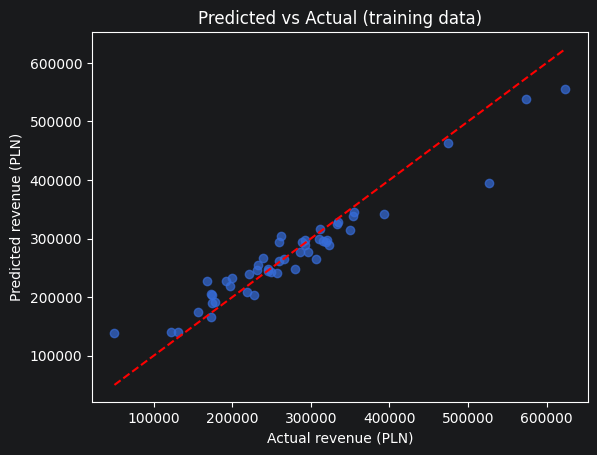

In [44]:
y_pred = xboost_model.predict(X)
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual revenue (PLN)')
plt.ylabel('Predicted revenue (PLN)')
plt.title('Predicted vs Actual (training data)')
plt.show()

The predicted vs actual plot on training data shows a very strong fit — a clear sign of overfitting. The model has memorized
the training set rather than learned generalizable patterns. This is expected given 26 features and 50 observations.

Cross-validation (R²=0.175) is the reliable estimate of generalization performance — this plot should not be interpreted as model quality.

In [45]:
from sklearn.metrics import root_mean_squared_error

baseline_pred = np.full(len(y), y.mean())
baseline_rmse = root_mean_squared_error(y, baseline_pred)
print(f"Baseline RMSE (always predict mean): {baseline_rmse:,.0f} PLN")
print(f"Model RMSE (CV): {-rmse_1.mean():,.0f} PLN")

Baseline RMSE (always predict mean): 106,966 PLN
Model RMSE (CV): 83,599 PLN


For whitespot scoring (Task 4), the model will be used as a relative ranking tool rather than an absolute revenue predictor: locations scoring in the top decile
are identified as expansion candidates regardless of the exact revenue estimate.